# **Spotify Dataset — Machine Learning and Feature Importance Analysis**

## **Import Libraries**

In [198]:
import sys
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import datetime
import pickle
try:
   import shap
except ImportError:
   subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
   import shap 
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

**A fixed random state is used to ensure reproducibility of machine learning experiments.**

In [199]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## **Project path Configuration**

In [200]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "cleaned_data.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

CLEANED_DATA_PATH = PROJECT_ROOT / "data" / "cleaned_data.csv"

## **Load Cleaned Dataset**

In [201]:
df = pd.read_csv(CLEANED_DATA_PATH)

## **Dataset Overview**

In [202]:
df.shape

(59721, 20)

In [203]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59721 entries, 0 to 59720
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          59721 non-null  str    
 1   artists           59721 non-null  str    
 2   album_name        59721 non-null  str    
 3   track_name        59721 non-null  str    
 4   popularity        59721 non-null  int64  
 5   duration_ms       59721 non-null  int64  
 6   explicit          59721 non-null  bool   
 7   danceability      59721 non-null  float64
 8   energy            59721 non-null  float64
 9   key               59721 non-null  int64  
 10  loudness          59721 non-null  float64
 11  mode              59721 non-null  int64  
 12  speechiness       59721 non-null  float64
 13  acousticness      59721 non-null  float64
 14  instrumentalness  59721 non-null  float64
 15  liveness          59721 non-null  float64
 16  valence           59721 non-null  float64
 17  temp

## **Feature Engineering**
- This section applies several feature engineering and preprocessing techniques to prepare the dataset for machine learning modeling.
- The process includes creating new variables from audio features, transforming numerical attributes, categorizing musical characteristics, encoding categorical variables, and optimizing feature representations to improve predictive performance and analytical quality.

### Drop unnecessary columns

In [204]:
df = df.drop(columns=['track_id', 'track_name', 'artists', 'album_name'])

### Convert Duration to Minutes

In [205]:
# create duration in minutes
df["duration_min"] = df["duration_ms"] / 60000

# remove duplicated information
df = df.drop(columns=["duration_ms"])

### Categorize Tempo


In [206]:
if 'tempo' in df.columns:
    df['tempo_category'] = pd.cut(df['tempo'],bins=[-1, 90, 140, df['tempo'].max() + 1],labels=['slow', 'medium', 'fast'])
df[['tempo', 'tempo_category']].head()

,tempo,tempo_category
0,87.917,slow
1,76.332,slow
2,119.949,medium
3,98.017,medium
4,150.960,fast


In [207]:
 # convert to string for encoding
df['tempo_category'] = df['tempo_category'].astype('str')
df[['tempo','tempo_category']].head()

,tempo,tempo_category
0,87.917,slow
1,76.332,slow
2,119.949,medium
3,98.017,medium
4,150.960,fast


### **Create new features**

### Creating Mood Categories from Audio Features
This section creates a new feature called `mood_category` based on the combination of energy and valence scores. 

According to Spotify audio feature definitions:
- Energy reflects the intensity and activity level of a track.
- Valence reflects the musical positivity or emotional tone.

By combining these two variables, songs can be categorized into different emotional moods to support listener behavior analysis and practical interpretation.

In [208]:
def mood_category(row):
    if row['energy'] > 0.6 and row['valence'] > 0.6:
        return 'Happy/Energetic'
    
    elif row['energy'] < 0.4 and row['valence'] < 0.4:
        return 'Sad/Chill'
    
    elif row['energy'] > 0.6 and row['valence'] < 0.4:
        return 'Aggressive'

    else:
        return 'Relaxing'

df['mood_category'] = df.apply(mood_category, axis=1)



### **Encoding and Data Transformation**
This section converts categorical and boolean variables into numerical representations suitable for machine learning algorithms.
The process includes:
- Converting boolean features into integer format
- Applying one-hot encoding to categorical variables
- Transforming dummy variables into numerical types for modeling compatibility

### Convert explicit from boolean to integer

In [209]:
if "explicit" in df.columns:
    df['explicit'] = df['explicit'].astype(int) 

df[['explicit']].head()

,explicit
0,0
1,0
2,0
3,0
4,0


### Encode Categorical Variables

In [210]:
categorical_columns = ['tempo_category','mood_category','track_genre']

existing_categorical_columns = [col for col in categorical_columns if col in df.columns]

df = pd.get_dummies(df,columns=existing_categorical_columns,drop_first=True)

df.head()

,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,...,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,73,0,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,...,False,False,False,False,False,False,False,False,False,False
1,57,0,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,...,False,False,False,False,False,False,False,False,False,False
2,82,0,0.618,0.443,2,-9.681,1,0.0526,0.4690,0.000000,...,False,False,False,False,False,False,False,False,False,False
3,58,0,0.688,0.481,6,-8.807,1,0.1050,0.2890,0.000000,...,False,False,False,False,False,False,False,False,False,False
4,80,0,0.703,0.444,11,-9.331,1,0.0417,0.5590,0.000000,...,False,False,False,False,False,False,False,False,False,False


### Convert Boolean Dummy Columns to integer

In [211]:
bool_cols = (df.select_dtypes(include=["bool"]).columns)
df[bool_cols] = (df[bool_cols].astype(int))
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59721 entries, 0 to 59720
Columns: 133 entries, popularity to track_genre_world-music
dtypes: float64(10), int64(123)
memory usage: 60.6 MB


### Encode Genre Categories

In [212]:
if "track_genre" in df.columns:
    df = pd.get_dummies(df, columns=['tempo_category'], drop_first=True)
df.head()

,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,...,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,73,0,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,...,0,0,0,0,0,0,0,0,0,0
1,57,0,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,...,0,0,0,0,0,0,0,0,0,0
2,82,0,0.618,0.443,2,-9.681,1,0.0526,0.4690,0.000000,...,0,0,0,0,0,0,0,0,0,0
3,58,0,0.688,0.481,6,-8.807,1,0.1050,0.2890,0.000000,...,0,0,0,0,0,0,0,0,0,0
4,80,0,0.703,0.444,11,-9.331,1,0.0417,0.5590,0.000000,...,0,0,0,0,0,0,0,0,0,0


## **Applying Regression Models**

### **Define Features and Target Variable**

In [213]:
if "popularity" not in df.columns:
    raise ValueError("The target column 'popularity' was not found in the dataset.")

X = df.drop(columns=["popularity"])
y = df["popularity"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Remaining non-numeric columns:", 
      X.select_dtypes(exclude=["number"]).columns.tolist())

X.head()

Features shape: (59721, 132)
Target shape: (59721,)
Remaining non-numeric columns: []


,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,...,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,0,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,...,0,0,0,0,0,0,0,0,0,0
1,0,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,...,0,0,0,0,0,0,0,0,0,0
2,0,0.618,0.443,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,...,0,0,0,0,0,0,0,0,0,0
3,0,0.688,0.481,6,-8.807,1,0.1050,0.2890,0.000000,0.1890,...,0,0,0,0,0,0,0,0,0,0
4,0,0.703,0.444,11,-9.331,1,0.0417,0.5590,0.000000,0.0973,...,0,0,0,0,0,0,0,0,0,0


### **Train-Test Split**

In [214]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape) 

X_train: (47776, 132)
X_test: (11945, 132)


### **Feature Scaling**

In [215]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **Train and Evaluate Machine Learning Models**

This section trains and evaluates multiple regression models to identify the most effective algorithm for predicting Spotify song popularity.

Different models are compared using several evaluation metrics:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

Scaling is selectively applied only to models that require standardized features.
Models to use: 
- Linear Regression
- Random Forest Regressor
- SVR
- Gradient Boosting Regressor
- KNN Regressor
- Decision Tree Regressor

### Initialize Models

In [216]:
models = {
    "Linear Regression": {"pipeline": Pipeline([("scaler", StandardScaler()),("model", LinearRegression())]),"params": {}},
    "Decision Tree Regressor": {"pipeline": Pipeline([("model", DecisionTreeRegressor(random_state=RANDOM_STATE))]),"params": {
            "model__max_depth": [5, 10, 20],
            "model__min_samples_split": [2, 5, 10]}},
    "Random Forest Regressor": {"pipeline": Pipeline([("model", RandomForestRegressor(random_state=RANDOM_STATE,n_jobs=-1))]),"params": {
            "model__n_estimators": [100,200,300],
            "model__max_depth": [None,10,20,30],
            "model__min_samples_split": [2,5,10],
            "model__min_samples_leaf": [1,2,4],
            "model__max_features": ["sqrt","log2",0.7],
            "model__bootstrap": [True]}},
    "Gradient Boosting Regressor": {"pipeline": Pipeline([("model", GradientBoostingRegressor(random_state=RANDOM_STATE))]),"params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [3, 5]}},
    "SVR": {"pipeline": Pipeline([("scaler", StandardScaler()),("model", SVR())]),"params": {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["rbf"],
            "model__gamma": ["scale", "auto"]}},
    "KNN Regressor": {"pipeline": Pipeline([("scaler", StandardScaler()),("model", KNeighborsRegressor())]),"params": {
            "model__n_neighbors": [3, 5, 7],
            "model__weights": ["uniform", "distance"]}}}

### Train and Evaluate Models

In this section, all machine learning models are trained using the training dataset and evaluated using the testing dataset.

Each model generates predictions on unseen data, and several regression evaluation metrics are calculated to assess model performance:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

The evaluation results and trained models are stored for further comparison and analysis.

In [217]:
results = {}

trained_models = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    pipeline = model["pipeline"]
    pipeline.fit(X_train, y_train)
    trained_models[model_name] = pipeline

    # predictions
    y_pred = pipeline.predict(X_test)

    # evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # store results
    results[model_name] = {"MAE": mae,"MSE": mse,"RMSE": rmse,"R2 Score": r2}

    # store trained models
    trained_models[model_name] = pipeline

print("All models have been trained successfully.")

Training Linear Regression...
Training Decision Tree Regressor...
Training Random Forest Regressor...
Training Gradient Boosting Regressor...
Training SVR...
Training KNN Regressor...
All models have been trained successfully.


### Model Performance Comparison

- The evaluation results are converted into a structured DataFrame to simplify model comparison.
- The models are ranked based on R² Score to identify the best-performing algorithm.

In [218]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="R2 Score",ascending=False)
results_df

,MAE,MSE,RMSE,R2 Score
Random Forest Regressor,11.503530,291.978152,17.087368,0.478226
KNN Regressor,14.241658,437.950396,20.927264,0.217368
Linear Regression,15.742967,443.223582,21.052876,0.207945
Gradient Boosting Regressor,17.400048,466.644629,21.601959,0.166091
SVR,14.333487,499.914476,22.358767,0.106637
Decision Tree Regressor,13.840255,525.456984,22.922849,0.060991


### **Observation:**
- Based on the model comparison results, the Random Forest Regressor achieved the best overall performance among all tested models. It obtained the highest R² Score (0.4782) and the lowest MSE (291.9781) and RMSE (17.0873), indicating better prediction accuracy and smaller prediction errors than the other models.

- Compared with Linear Regression, Random Forest performed significantly better, suggesting that the relationship between Spotify audio features and song popularity is non-linear. Although KNN Regressor achieved a relatively competitive MAE, its R² Score remained lower, meaning it was less effective at explaining overall popularity variation.

- Overall, Random Forest is more suitable for this problem because it can capture complex feature interactions and non-linear patterns. Therefore, it was selected as the best baseline model for further hyperparameter tuning and SHAP explainability analysis.

### Visualize Model Performance

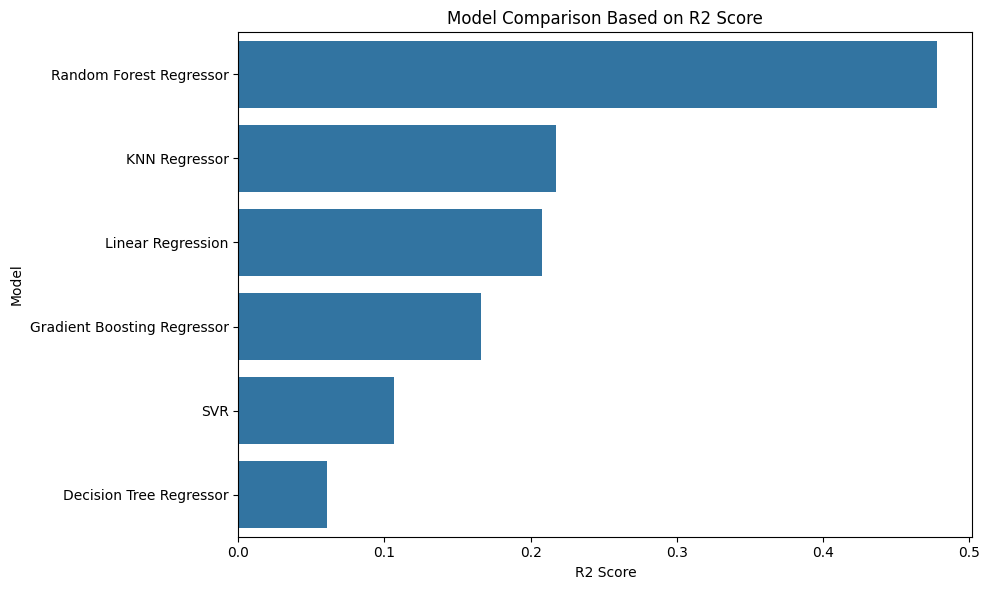

In [219]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df,x="R2 Score",y=results_df.index)
plt.title("Model Comparison Based on R2 Score")
plt.xlabel("R2 Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

### Select Best Model

In [220]:
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]
print(f"Best Model: {best_model_name}")


Best Model: Random Forest Regressor


### Cross-Validation
- Cross-validation is performed to evaluate the generalization ability of the best-performing model.
- This process reduces the risk of overfitting and provides a more reliable estimate of model performance.

In [221]:
print(f"Cross-Validation for {best_model_name}")

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1)

print("CV R2 Scores:", np.round(cv_scores, 4))
print("Average CV R2:", np.mean(cv_scores))

Cross-Validation for Random Forest Regressor
CV R2 Scores: [0.4592 0.4497 0.4469 0.4439 0.4643]
Average CV R2: 0.4527792297449027


## **Hyperparameter Tuning**
RandomizedSearchCV is used to optimize the hyperparameters of the best-performing Random Forest model.

In [222]:
rf_pipeline = models["Random Forest Regressor"]["pipeline"]
rf_params = models["Random Forest Regressor"]["params"]
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=10,
    cv=5,
    scoring='r2',
    random_state=RANDOM_STATE,
    n_jobs=-1)
random_search.fit(X_train, y_train)
best_rf = random_search.best_estimator_
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None, 'model__bootstrap': True}


### **Evaluate Final Model Performance**

This section evaluates the performance of the final machine learning model using regression metrics and prediction results.

In [223]:
# make final predictions
y_pred_final = best_rf.predict(X_test)

# evaluation metrics
final_mae = mean_absolute_error(y_test,y_pred_final)
final_mse = mean_squared_error(y_test,y_pred_final)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test,y_pred_final)

# create results table
final_results = pd.DataFrame({
    'Metric': [
        'MAE',
        'MSE',
        'RMSE',
        'R2 Score'],
    'Value': [
        final_mae,
        final_mse,
        final_rmse,
        final_r2]})
final_results

,Metric,Value
0,MAE,12.984975
1,MSE,307.158556
2,RMSE,17.525940
3,R2 Score,0.451098


### **Plot Actual vs Predicted Popularity**

This visualization compares actual popularity values with predicted popularity values generated by the final model.

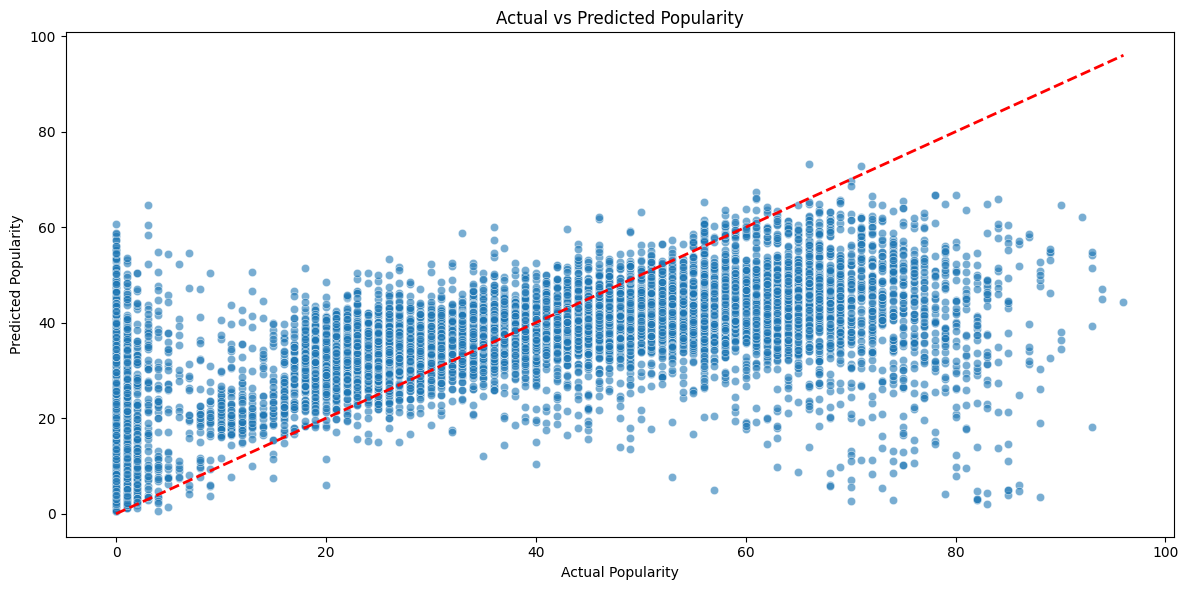

In [224]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=y_test,y=y_pred_final,alpha=0.6)
# reference line
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color='red',lw=2,linestyle='--')
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Actual vs Predicted Popularity")
plt.tight_layout()
plt.show()

**Observation:**
- The scatter plot shows that the model has successfully captured the overall positive relationship between actual popularity and predicted popularity, as the data points generally follow an upward trend along the diagonal reference line.
- However, the predicted values remain relatively dispersed around the diagonal reference line, indicating that prediction errors are still noticeable. In particular, the model tends to predict within a narrower range compared to the actual popularity distribution.

- Despite these limitations, the model demonstrates acceptable generalization ability and does not exhibit severe overfitting. The results suggest that music popularity is a complex phenomenon influenced not only by audio characteristics but also by external factors such as artist reputation, social media trends, playlist exposure, and marketing strategies that are not included in the current dataset.

### **Residual Analysis**

Residual analysis is performed to evaluate prediction error distribution.

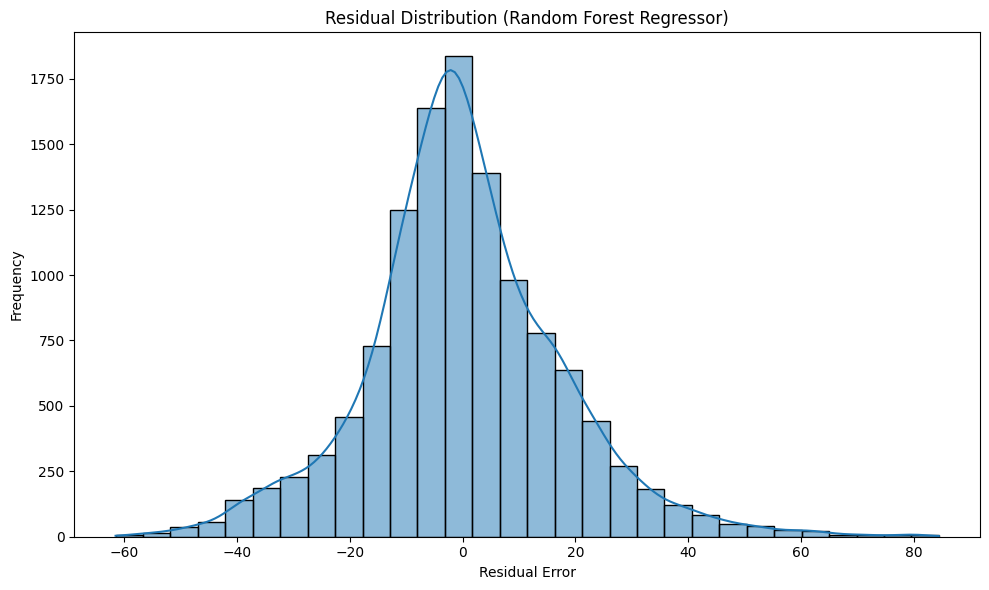

In [225]:
# predictions from best model
y_pred_best = best_rf.predict(X_test)

# calculate residuals
residuals = y_test - y_pred_best
plt.figure(figsize=(10, 6))
sns.histplot(residuals,bins=30,kde=True)
plt.title(f"Residual Distribution ({best_model_name})")
plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Observation:**
- Residual analysis indicates that prediction errors are generally centered around zero and approximately normally distributed. This suggests that the model achieves relatively stable generalization performance and does not exhibit severe prediction bias. 
- Although a slight positive skew and several outliers are observed, the overall residual pattern remains acceptable for a real-world regression problem.

### **Feature Importance Analysis**

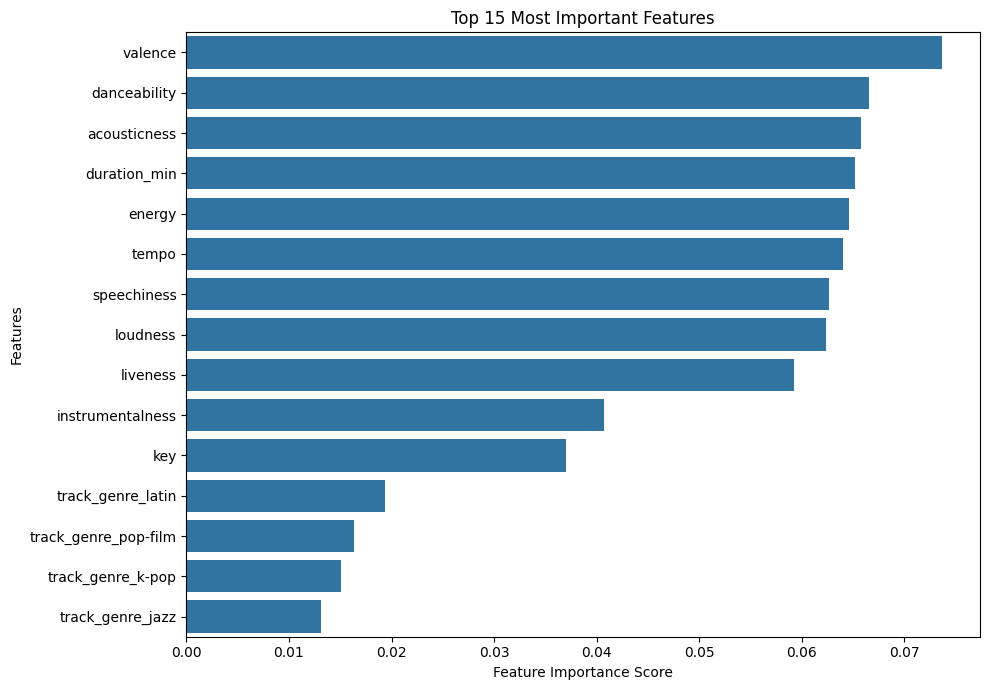

,Feature,Importance
10,valence,0.073688
1,danceability,0.066539
7,acousticness,0.065749
13,duration_min,0.065209
2,energy,0.064634
11,tempo,0.064020
6,speechiness,0.062695
4,loudness,0.062369
9,liveness,0.059224
8,instrumentalness,0.040707


In [226]:
rf_model = best_rf.named_steps['model']
feature_importance = pd.DataFrame({"Feature": X.columns,"Importance": rf_model.feature_importances_})
feature_importance = feature_importance.sort_values(by="Importance",ascending=False)
# select top 15 features
top15_features = feature_importance.head(15)
# visualize feature importance
plt.figure(figsize=(10, 7))
sns.barplot(data=top15_features,x="Importance",y="Feature")

plt.title("Top 15 Most Important Features")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()
top15_features

**Observation:**
+ The feature importance analysis indicates that valence is the most influential feature in predicting music popularity, followed by danceability, acousticness, duration_min, and energy. This suggests that listeners tend to prefer songs with more positive emotional tones, higher rhythmic appeal, and energetic characteristics. Features such as tempo, loudness, speechiness, and liveness also contribute substantially to the prediction model, indicating that both musical dynamics and production-related attributes affect audience preferences.

+ Interestingly, several genre-related variables, including track_genre_latin, track_genre_pop-film, track_genre_k-pop, and track_genre_jazz, appear among the top important features, although their importance scores are lower compared to audio characteristics. This implies that audio features have a stronger impact on popularity prediction than genre categories alone.

+ Overall, the results suggest that song popularity is primarily driven by musical and emotional attributes rather than solely by genre labels. The model highlights the importance of creating energetic, emotionally engaging, and rhythmically appealing songs to increase mainstream popularity.

## **SHAP Explainability**

### **SHAP Analysis**

SHAP analysis is used to interpret feature contributions and explain how different variables influence model predictions.

In [227]:
X_test_sample = X_test.sample(300, random_state=RANDOM_STATE)
rf_model = best_rf.named_steps['model']
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_sample,check_additivity=False)
print("SHAP values calculated successfully.")

SHAP values calculated successfully.


### **SHAP Summary Plot**
This plot shows both feature importance and direction of impact.


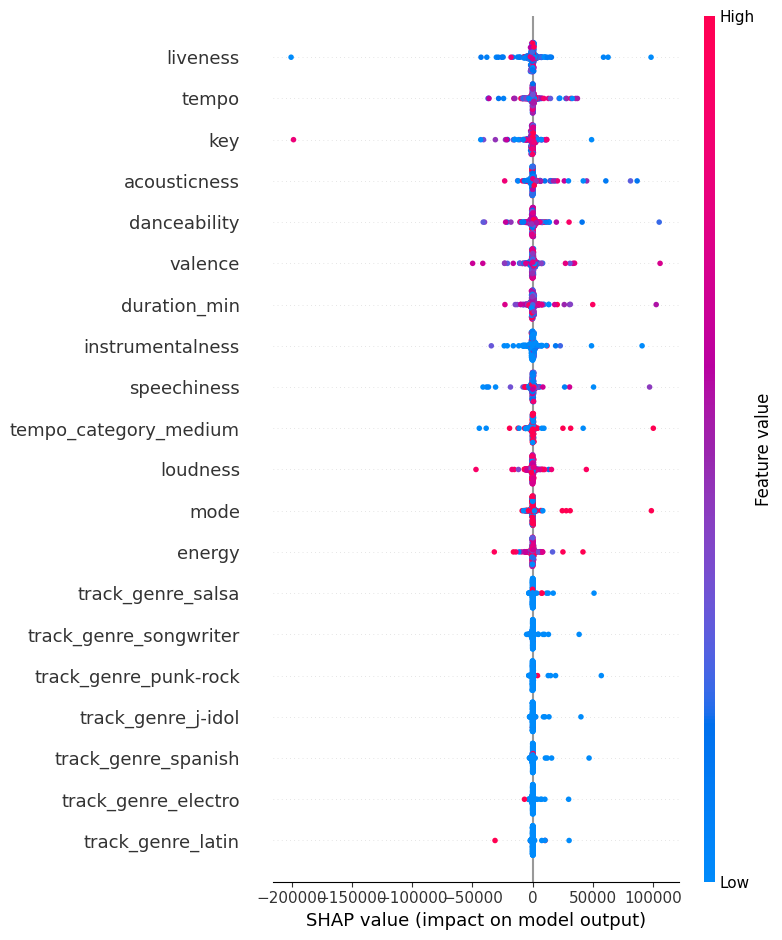

In [232]:
shap.summary_plot(shap_values,X_test_sample)

### **SHAP Bar Plot**
This plot ranks features by average absolute SHAP value.


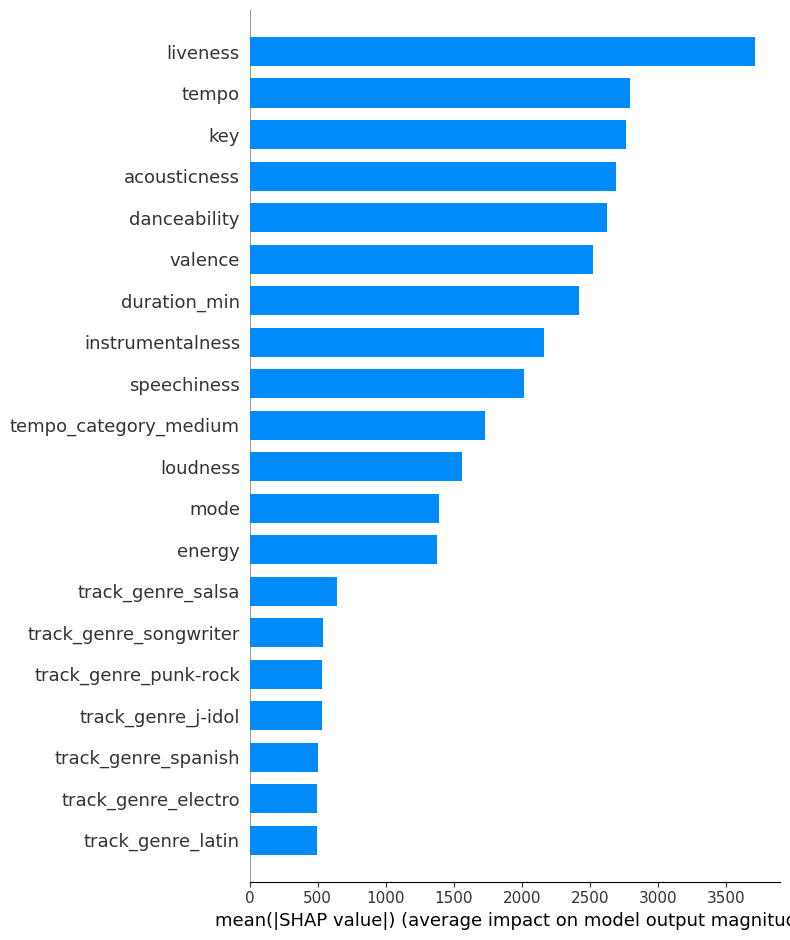

In [233]:
shap.summary_plot(shap_values,X_test_sample,plot_type="bar")


### Create SHAP importance table


In [235]:
shap_importance = pd.DataFrame({"Feature": X_test_sample.columns,"Mean_SHAP_Value": np.abs(shap_values).mean(axis=0)})

shap_importance = shap_importance.sort_values(by="Mean_SHAP_Value",ascending=False)
shap_importance.head(15)

,Feature,Mean_SHAP_Value
9,liveness,3708.987256
11,tempo,2794.285251
3,key,2765.471333
7,acousticness,2692.747526
1,danceability,2626.823395
10,valence,2524.113334
13,duration_min,2419.061146
8,instrumentalness,2164.095795
6,speechiness,2014.475607
14,tempo_category_medium,1729.153070


## **SHAP Interpretation and Feature Importance Analysis**
- The SHAP summary plot and SHAP importance table provide interpretable insights into how **different audio characteristics** contribute to **music popularity prediction**. Based on the SHAP mean importance values, features such as **liveness, tempo, key, acousticness, danceability, valence, duration_min, instrumentalness, and speechiness** appear among the most influential predictors in the model.

- Among these variables, **liveness** has the highest **SHAP importance score**, suggesting that **live-performance characteristics** strongly influence popularity prediction. This finding can be considered reasonable because songs that create a more **immersive, energetic, or concert-like atmosphere** may generate **stronger emotional engagement and audience interest**, especially in modern digital music consumption and live entertainment contexts.

- **Tempo, danceability, loudness, and energy** also demonstrate relatively high importance. These features are closely associated with rhythm intensity, musical excitement, and listener engagement. In practice, audiences often prefer songs that are **energetic, rhythmic, and emotionally stimulating**, particularly for activities such as workouts, social gatherings, short-form video content, and music events. Therefore, the importance of these variables aligns well with common music listening behavior.

- In addition, **valence and acousticness** appear meaningful because they reflect **emotional mood and musical atmosphere**. Valence measures the positivity of a song, while acousticness captures acoustic sound characteristics. Listener preferences are frequently influenced by **emotional tone and listening experience**, making these features logically related to popularity differences across songs.

- The importance of **duration_min** is also understandable because song duration may **affect listener retention and streaming behavior**. Songs with moderate durations are generally more suitable for **repeated listening and platform consumption patterns, potentially increasing streaming frequency and popularity.**

- Interestingly, variables related to **specific music genres**, such as **salsa** and **songwriter**, have relatively lower SHAP importance scores compared to general audio characteristics. This suggests that music popularity may depend more heavily on overall listening experience, emotional engagement, and musical composition rather than genre labels alone.

**Overall**, the SHAP analysis indicates that the model captures several realistic behavioral patterns in consumer music preferences. The identified important features are generally consistent with contemporary digital music trends and provide meaningful practical implications for music producers, artists, and event organizers seeking to better understand audience listening behavior.

## **Consumer Listening Behavior and Practical Implications**
- Based on the popularity prediction results and SHAP analysis, consumer listening behavior appears to be strongly influenced by audio characteristics related to energy, rhythm, emotional atmosphere, and listener engagement. Features such as liveness, danceability, tempo, loudness, and valence play important roles in determining music popularity on digital platforms.

- The findings suggest that listeners tend to prefer songs that are energetic, rhythmic, emotionally engaging, and suitable for modern digital music consumption behaviors such as streaming, workouts, short-form videos, and live entertainment experiences.

- From a **practical perspective**, **music producers and artists** may use these insights to develop songs that better align with audience preferences and current market trends. In addition, event organizers and entertainment managers may also apply these findings when selecting music for concerts, festivals, and entertainment events to enhance audience engagement and emotional atmosphere.

**In conclusion**, the analysis not only supports music popularity prediction but also provides meaningful insights into consumer listening behavior and decision-making within the music and entertainment industry.

## **Saving model**

In [237]:
with open('random_forest_regressor_model.pkl', 'wb') as file:
    pickle.dump(best_rf, file)